#Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#Loading dataset

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Big Data/spotify_tracks.csv")

print(df.head())

                 track_id                    track_name     artist_name  \
0  P3fAbnFbmOHnKYaXRvj7uf  One Dance (Acoustic Version)  Alex Rodriguez   
1  M2wleOV911xCZkwPRQeNHp          Forever Song (Remix)     Desert Wind   
2  4JSnE2NiiUHUAKw9iEU1jj                 Last Mountain    The Midnight   
3  2UVvsjaSS8VFgM0Fmxk754           Falling Star (Live)    Phantom Keys   
4  EeVVhDIq2AnHTmt9OBGhnu   Rising Moon (feat. someone)     Desert Wind   

                album_name  release_year  genre  popularity  duration_ms  \
0          The Night Album          2024  metal          14       189042   
1             Burning Soul          2019   rock          11       186805   
2          The Night Album          2022  k-pop          23       121814   
3  Phantom's Greatest Hits          2024  latin          34       216049   
4              Rising Soul          2010  latin          31       156170   

   explicit  danceability  ...  loudness  speechiness  acousticness  \
0      True      0.42

#Data type and information

In [3]:
print(df.shape)

print(df.info())

print(df.describe())

(50000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_id          50000 non-null  object 
 1   track_name        50000 non-null  object 
 2   artist_name       50000 non-null  object 
 3   album_name        50000 non-null  object 
 4   release_year      50000 non-null  int64  
 5   genre             50000 non-null  object 
 6   popularity        50000 non-null  int64  
 7   duration_ms       50000 non-null  int64  
 8   explicit          50000 non-null  bool   
 9   danceability      50000 non-null  float64
 10  energy            50000 non-null  float64
 11  loudness          50000 non-null  float64
 12  speechiness       50000 non-null  float64
 13  acousticness      50000 non-null  float64
 14  instrumentalness  50000 non-null  float64
 15  liveness          50000 non-null  float64
 16  valence           50000 non-

In [4]:
print(df.isnull().sum())

track_id            0
track_name          0
artist_name         0
album_name          0
release_year        0
genre               0
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
key                 0
mode                0
time_signature      0
dtype: int64


In [5]:
df = df.dropna()

In [6]:
df["duration_min"] = df["duration_ms"] / 60000

In [7]:
df = df.drop(["track_id"], axis=1)

#Popular songs

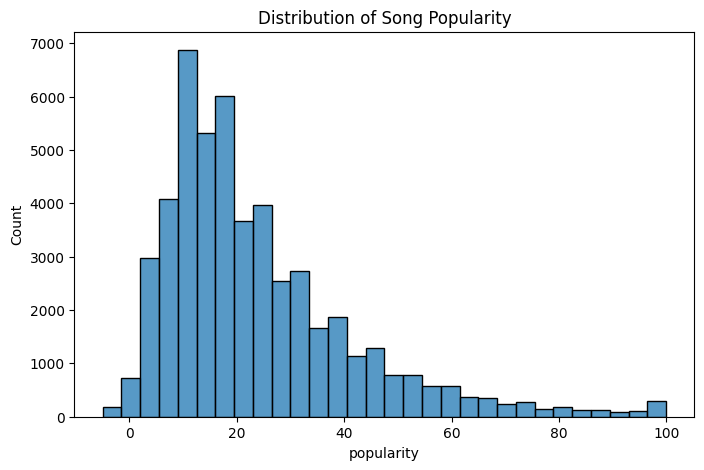

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df["popularity"], bins=30)
plt.title("Distribution of Song Popularity")
plt.show()

#Top 10 genre

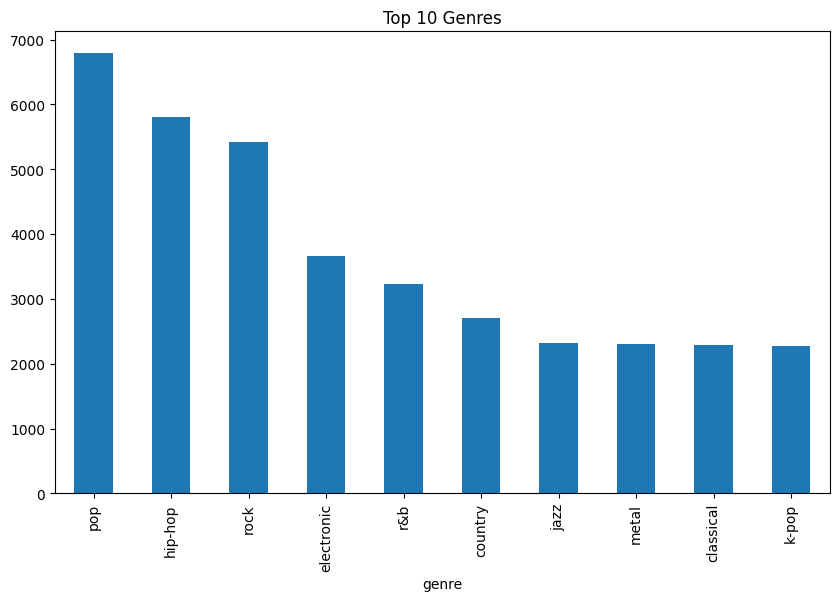

In [9]:
plt.figure(figsize=(10,6))
df["genre"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Genres")
plt.show()

#Histrogram


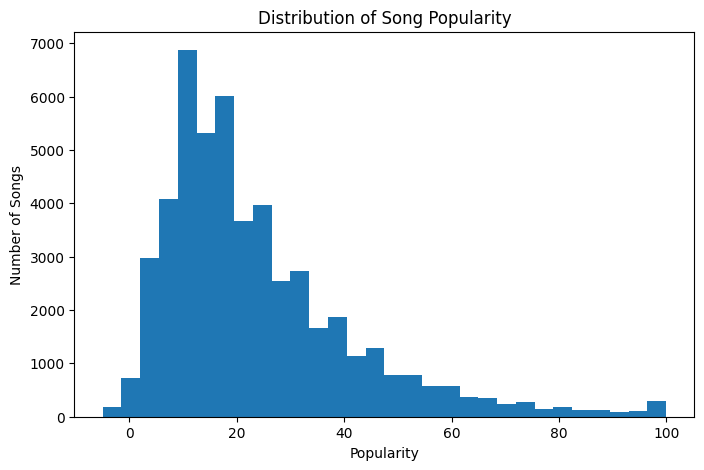

In [18]:
plt.figure(figsize=(8,5))
plt.hist(df["popularity"], bins=30)

plt.title("Distribution of Song Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")

plt.show()

In [20]:
audio_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

In [21]:
genre_avg = df.groupby("genre")[audio_features].mean()

print(genre_avg)

               danceability    energy   loudness  speechiness  acousticness  \
genre                                                                         
ambient            0.250055  0.185659 -17.807170     0.036243      0.552319   
blues              0.517610  0.506806 -10.950936     0.051406      0.547890   
classical          0.252256  0.250483 -15.020991     0.044116      0.873432   
country            0.601050  0.617833  -7.536790     0.042050      0.480167   
drum-and-bass      0.756422  0.889367  -6.232370     0.043555      0.062396   
electronic         0.780027  0.841001  -5.608318     0.052213      0.078852   
folk               0.448258  0.379764 -12.033200     0.044117      0.814228   
gospel             0.605039  0.651051  -7.960607     0.070818      0.425797   
hip-hop            0.816443  0.679998  -6.085443     0.219806      0.112541   
indie              0.548230  0.597898  -7.972413     0.052410      0.377321   
jazz               0.552357  0.397439 -11.991881    

In [22]:
genre_popularity = df.groupby("genre")["popularity"].mean().sort_values(ascending=False)

print(genre_popularity)

genre
rock             24.345763
indie            24.047407
jazz             23.827497
ambient          23.807777
reggae           23.724856
folk             23.709406
electronic       23.666303
punk             23.565353
blues            23.552758
pop              23.526525
k-pop            23.523956
gospel           23.475771
r&b              23.465555
country          23.450000
hip-hop          23.440964
latin            23.393032
classical        23.237555
soul             23.228959
metal            23.120727
drum-and-bass    22.702174
Name: popularity, dtype: float64


#Average Energy per Genre

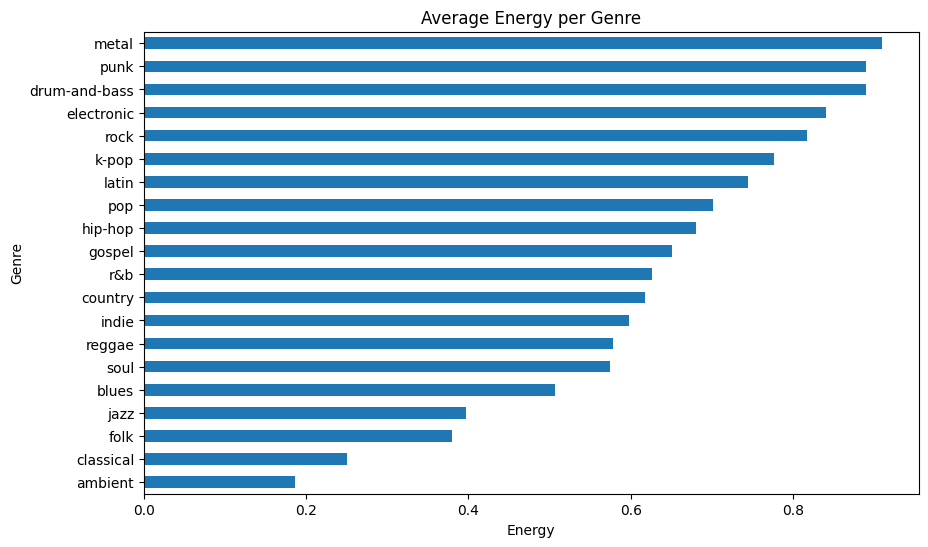

In [24]:
genre_avg["energy"].sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Average Energy per Genre")
plt.xlabel("Energy")
plt.ylabel("Genre")

plt.show()

#Top 10 Genres by Average Popularity

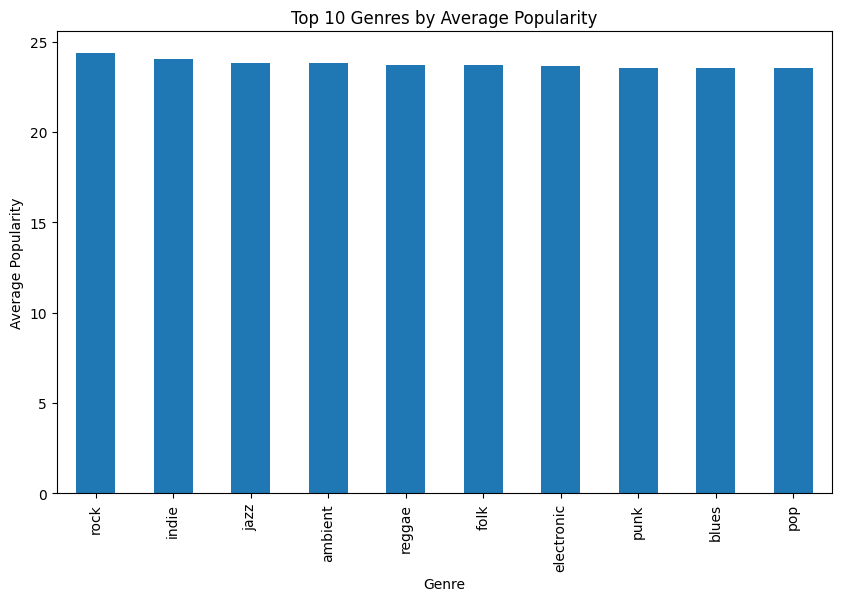

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/drive/MyDrive/Big Data/spotify_tracks.csv")

genre_popularity = df.groupby("genre")["popularity"].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
genre_popularity.head(10).plot(kind="bar")

plt.title("Top 10 Genres by Average Popularity")
plt.xlabel("Genre")
plt.ylabel("Average Popularity")

plt.show()

#Top Artists with Most Songs

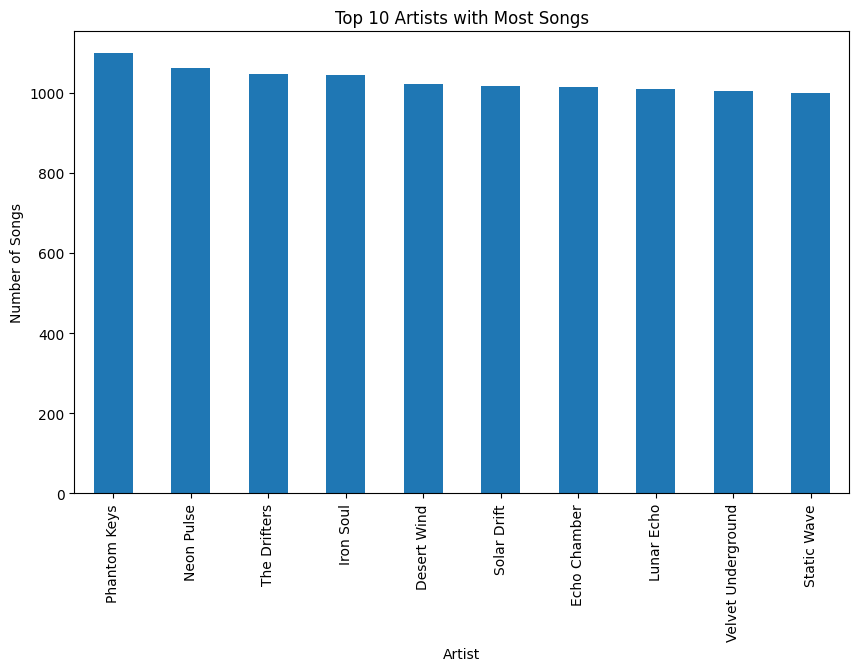

In [31]:
top_artists = df["artist_name"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_artists.plot(kind="bar")

plt.title("Top 10 Artists with Most Songs")

plt.xlabel("Artist")
plt.ylabel("Number of Songs")

plt.show()

#Popular vs Non-Popular Songs

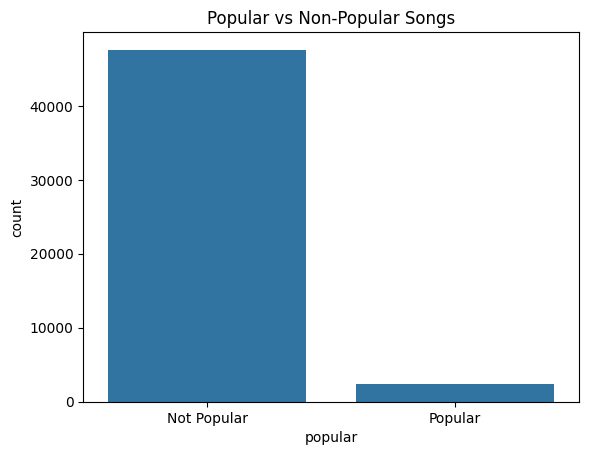

In [32]:
df["popular"] = df["popularity"].apply(lambda x: "Popular" if x > 60 else "Not Popular")

sns.countplot(x="popular", data=df)

plt.title("Popular vs Non-Popular Songs")

plt.show()

#Select Audio Features

In [33]:
audio_features = [
    "danceability",
    "energy",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

#Plot Distribution of Each Audio Feature

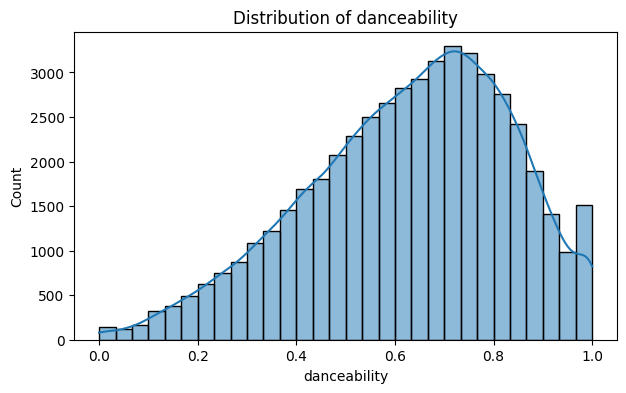

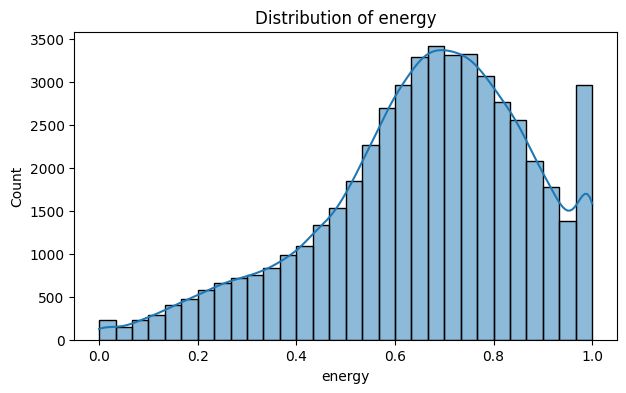

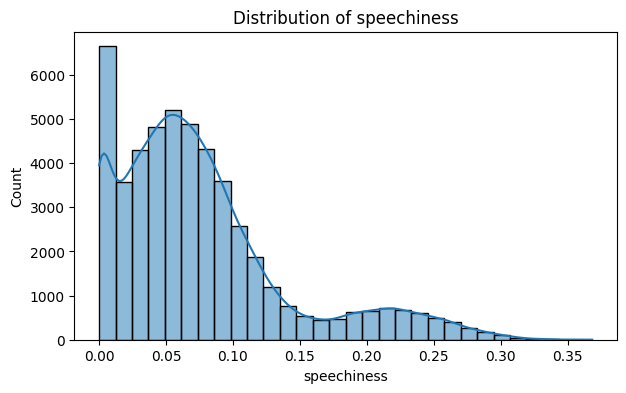

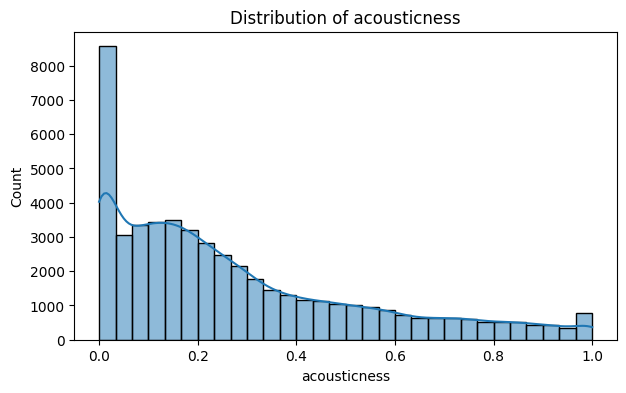

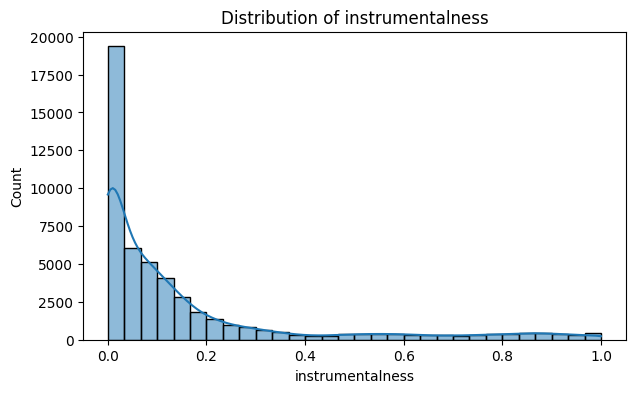

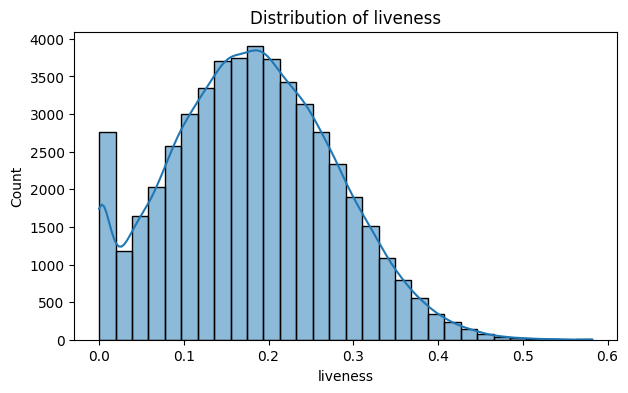

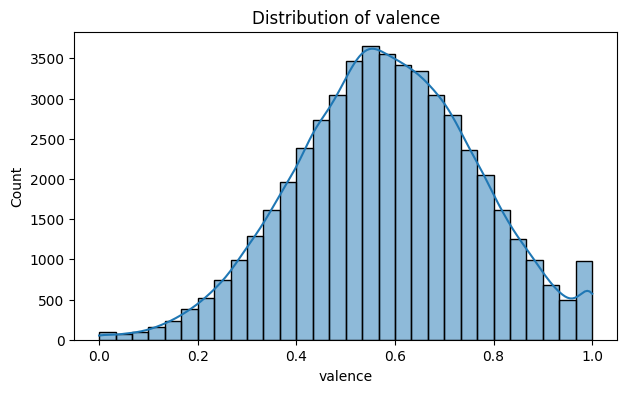

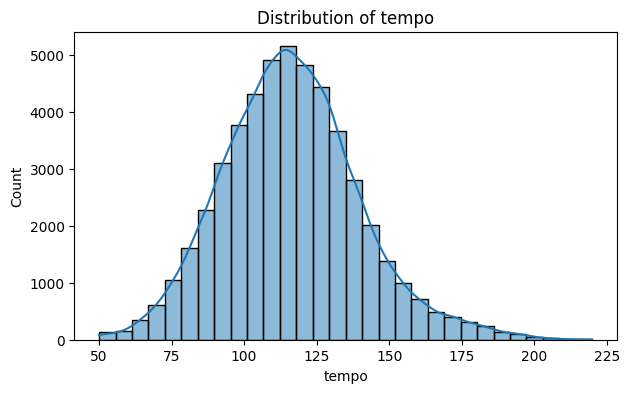

In [34]:
for feature in audio_features:

    plt.figure(figsize=(7,4))

    sns.histplot(df[feature], bins=30, kde=True)

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Count")

    plt.show()

#Combined Distribution Plot

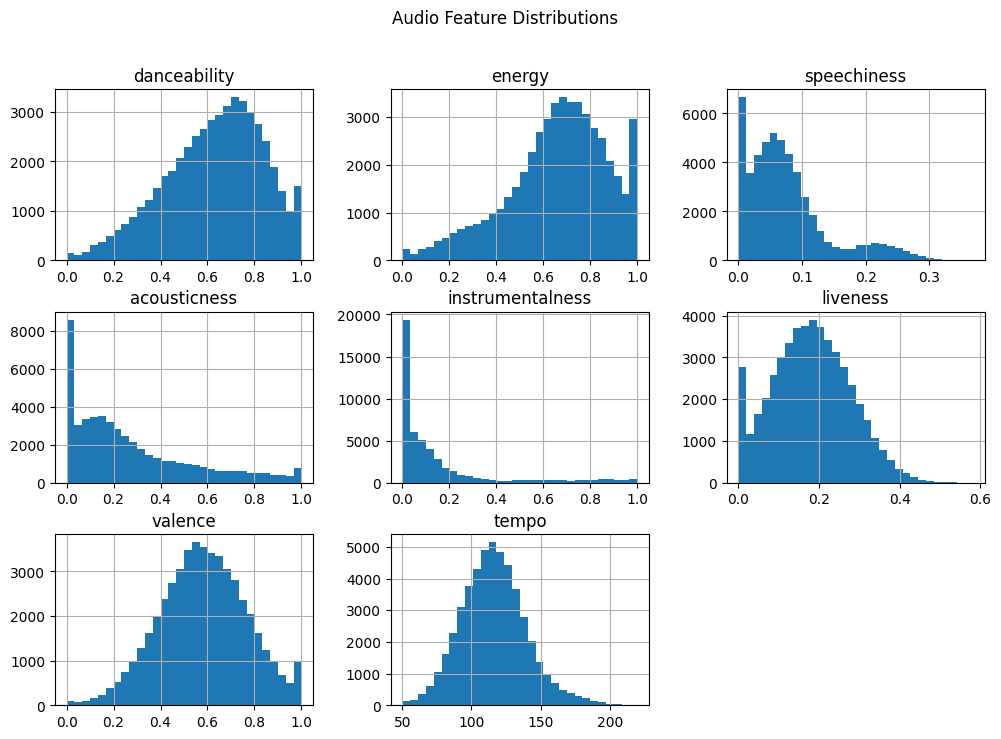

In [35]:
df[audio_features].hist(
    figsize=(12,8),
    bins=30
)

plt.suptitle("Audio Feature Distributions")

plt.show()

#Box Plot

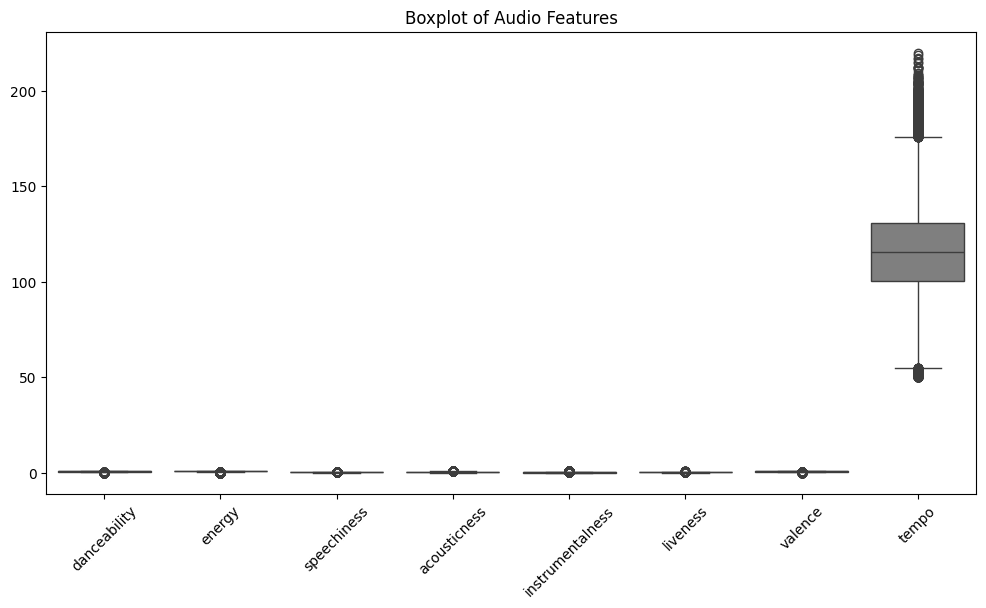

In [36]:
plt.figure(figsize=(12,6))

sns.boxplot(data=df[audio_features])

plt.title("Boxplot of Audio Features")

plt.xticks(rotation=45)

plt.show()

#KDE Distribution Plot

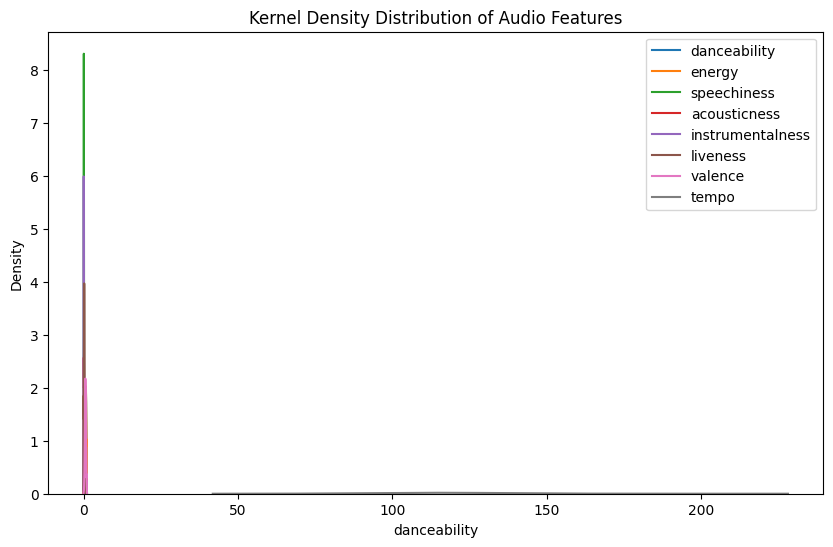

In [37]:
plt.figure(figsize=(10,6))

for feature in audio_features:
    sns.kdeplot(df[feature], label=feature)

plt.title("Kernel Density Distribution of Audio Features")

plt.legend()

plt.show()

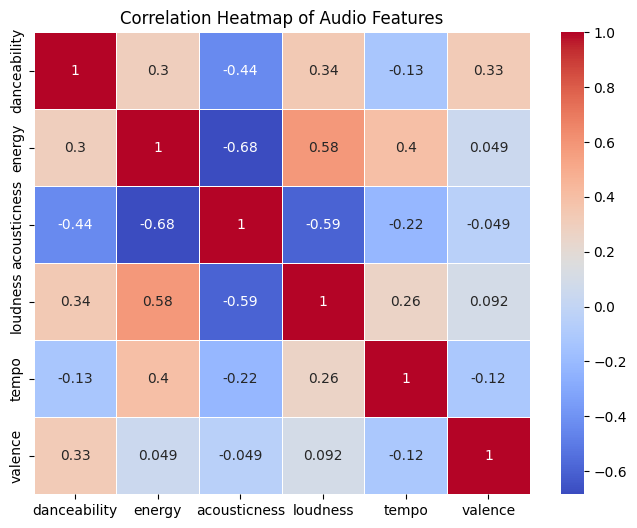

In [38]:
features = ["danceability", "energy", "acousticness", "loudness", "tempo", "valence"]

# Compute correlation matrix
corr_matrix = df[features].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap of Audio Features")
plt.show()

#Yearly Trends

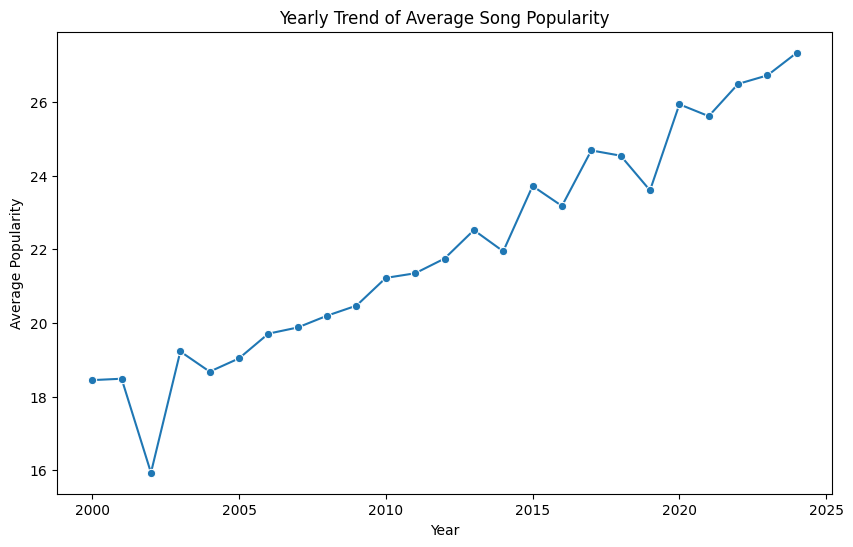

In [40]:
df["year"] = df["release_year"]

# Calculate average popularity per year
yearly_popularity = df.groupby("year")["popularity"].mean()

# Plot yearly trend
plt.figure(figsize=(10,6))
sns.lineplot(x=yearly_popularity.index, y=yearly_popularity.values, marker="o")

plt.title("Yearly Trend of Average Song Popularity")
plt.xlabel("Year")
plt.ylabel("Average Popularity")

plt.show()